<a href="https://colab.research.google.com/github/jvestevesdacunha/Trabalho_PAA/blob/main/Trabalho_de_PAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabalho de Projeto e Análise de Algoritmos:
    Aluno: João Vitor Esteves da Cunha
    Matrícula: 2023100053611
    Algoritmos: Quick-sort, Insertion-sort


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time
import sys
sys.setrecursionlimit(100000)

def quick_sort(lista):
    if len(lista) <= 1:
        return lista
    else:
        meio = len(lista) // 2
        pv = lista[meio]

        restante = lista[:meio] + lista[meio+1:]
        menores = [x for x in restante if x <= pv]
        maiores = [x for x in restante if x > pv]
        return quick_sort(menores) + [pv] + quick_sort(maiores)

# Verificando o funcionamento:
dados1 = [10, 7, 8, 9, 1, 5]
print("Quick Sort:", quick_sort(dados1))


Quick Sort: [1, 5, 7, 8, 9, 10]


In [ ]:
def insertion_sort(lista):
    for i in range(1, len(lista)):
        chave = lista[i]
        j = i - 1
        while j >= 0 and lista[j] > chave:
            lista[j + 1] = lista[j]
            j -= 1
        lista[j + 1] = chave
    return lista

# Verificando o funcionamento:
dados = [10, 7, 8, 9, 1, 5]
print("Insertion Sort:", insertion_sort(dados))


Insertion Sort: [1, 5, 7, 8, 9, 10]



Tamanho: 50
  Crescente    - Quick Sort     : 0.000074 s
  Crescente    - Insertion Sort : 0.000007 s
  Decrescente  - Quick Sort     : 0.000054 s
  Decrescente  - Insertion Sort : 0.000124 s
  Aleatório    - Quick Sort     : 0.000072 s
  Aleatório    - Insertion Sort : 0.000046 s

Tamanho: 500
  Crescente    - Quick Sort     : 0.000703 s
  Crescente    - Insertion Sort : 0.000065 s
  Decrescente  - Quick Sort     : 0.000492 s
  Decrescente  - Insertion Sort : 0.009936 s
  Aleatório    - Quick Sort     : 0.000851 s
  Aleatório    - Insertion Sort : 0.004858 s

Tamanho: 5000
  Crescente    - Quick Sort     : 0.009121 s
  Crescente    - Insertion Sort : 0.000955 s
  Decrescente  - Quick Sort     : 0.006838 s
  Decrescente  - Insertion Sort : 1.137029 s
  Aleatório    - Quick Sort     : 0.010945 s
  Aleatório    - Insertion Sort : 0.581110 s

Tamanho: 50000
  Crescente    - Quick Sort     : 0.080564 s
  Crescente    - Insertion Sort : 0.006016 s
  Decrescente  - Quick Sort     : 0.079561

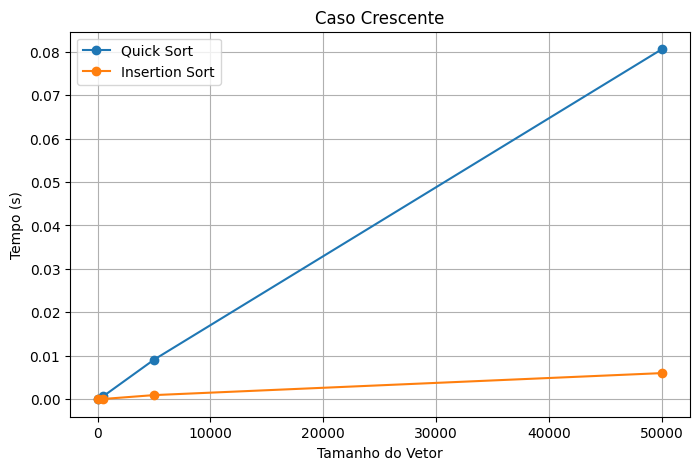

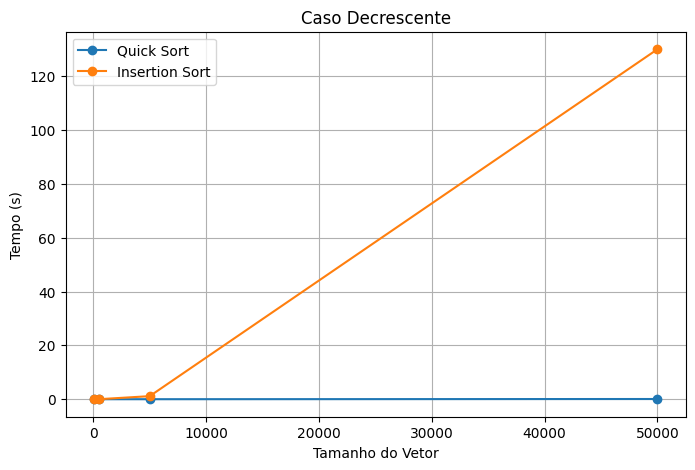

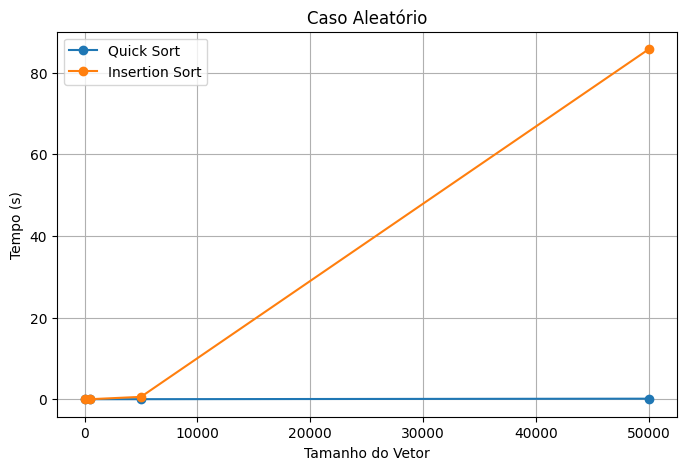

In [ ]:

import time
import random
import matplotlib.pyplot as plt

def duracao(func, vetor):
    vet = vetor.copy()
    inicio = time.time()
    func(vet)
    fim = time.time()
    return fim - inicio

def testar_e_plotar(nome_algoritmo, algoritmo):
    tamanhos = [50, 500, 5000, 50000]
    casos = {
        'Crescente': lambda n: list(range(n)),
        'Decrescente': lambda n: list(range(n, 0, -1)),
        'Aleatório': lambda n: random.sample(range(n * 10), n)
    }

    algoritmos = {
        "Quick Sort": quick_sort,
        "Insertion Sort": insertion_sort
        }

    tempos = {caso: {nome: [] for nome in algoritmos} for caso in casos}

    for tamanho in tamanhos:
        print(f"\nTamanho: {tamanho}")
        for nome_caso, gerador in casos.items():
            vetor = gerador(tamanho)
            for nome_alg, algoritmo_func in algoritmos.items():
                tempo = duracao(algoritmo_func, vetor)
                tempos[nome_caso][nome_alg].append(tempo)
                print(f"  {nome_caso:<12} - {nome_alg:<15}: {tempo:.6f} s")


    for nome_caso in casos:
        plt.figure(figsize=(8, 5))
        for nome_alg, lista_tempos in tempos[nome_caso].items():
            plt.plot(tamanhos, lista_tempos, marker='o', label=nome_alg)
        plt.title(f'Caso {nome_caso}')
        plt.xlabel('Tamanho do Vetor')
        plt.ylabel('Tempo (s)')
        plt.legend()
        plt.grid(True)
        plt.show()

testar_e_plotar("Comparação", None)
